# Linear Regression (Assignment 1)

This notebook completes Q1(a)-Q1(c) for all linear datasets.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.metrics import MSE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import get_train_val
from model.linear_model import LinearModel

seed = 42  # do not change
np.random.seed(seed)

DATASETS = [
    'linear_data_A',
    'linear_data_B',
    'linear_data_C',
    'linear_data_D',
]
LEARNING_RATES = [0.1, 0.01, 0.001]
N_ITERATION = 500

asset_dir = Path('report_assets/linear_regression')
asset_dir.mkdir(parents=True, exist_ok=True)


def save_markdown_table(df, path, float_digits=4):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].map(lambda v: f"{v:.{float_digits}f}")
    header = '| ' + ' | '.join(out.columns) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(out.columns)) + ' |'
    rows = ['| ' + ' | '.join(map(str, row)) + ' |' for row in out.to_numpy()]
    path.write_text('\n'.join([header, sep, *rows]), encoding='utf-8')


def save_loss_curve(train_losses, val_losses, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(len(train_losses)), train_losses, color='tab:red', linewidth=1.2, label='Training loss')
    ax.plot(range(len(val_losses)), val_losses, color='tab:green', linewidth=1.2, label='Validation loss')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()


def run_single_experiment(dataset_name, learning_rate):
    loaded_data = np.load(f'data/linear_data/{dataset_name}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    dim = X.shape[1] - 1

    np.random.seed(seed)
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    model = LinearModel(dim=dim, is_reg=True, loss_fn=MSE, grad_fn=MSE_grad)
    model.fit(
        X_train,
        y_train,
        lr=learning_rate,
        n_iteration=N_ITERATION,
        val_ratio=0.2,
        verbose=False,
        plot_curve=False
    )

    lr_tag = str(learning_rate).replace('.', 'p')
    loss_path = asset_dir / f'{dataset_name}_loss_lr_{lr_tag}.png'
    save_loss_curve(
        model.train_losses,
        model.val_losses,
        title=f'{dataset_name} - Loss Curve (lr={learning_rate})',
        save_path=loss_path
    )

    y_val_pred = model.predict(X_val)
    metrics = evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'{dataset_name} Evaluation (lr={learning_rate})'
    )

    return {
        'dataset': dataset_name,
        'learning_rate': learning_rate,
        **metrics,
        'loss_curve_path': str(loss_path),
    }


## Q1(a) and Q1(b): Learning Rate Sweep + Evaluation

Dataset: linear_data_A
--------------------------------------------------------------------------------
Running lr=0.1


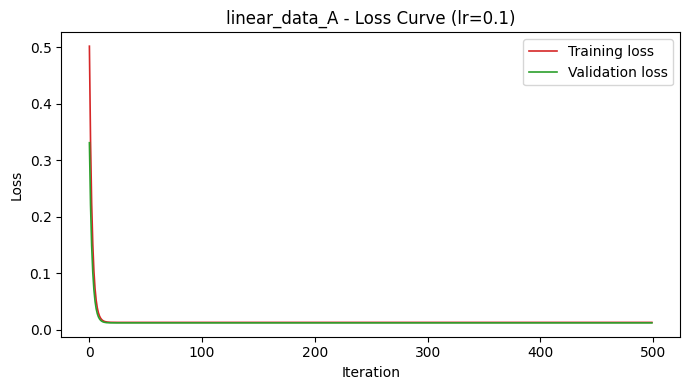

=== linear_data_A Evaluation (lr=0.1) ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
--------------------------------------------------------------------------------
Running lr=0.01


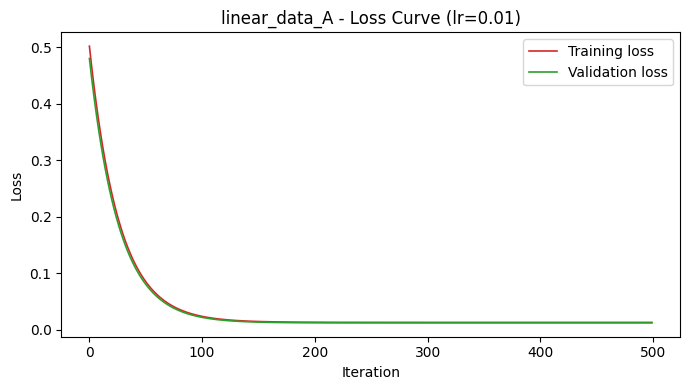

=== linear_data_A Evaluation (lr=0.01) ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
--------------------------------------------------------------------------------
Running lr=0.001


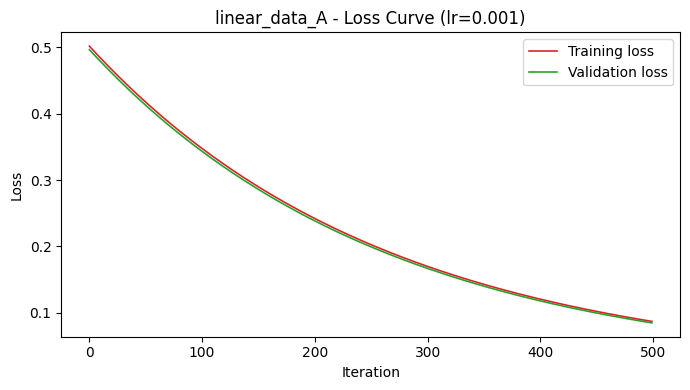

=== linear_data_A Evaluation (lr=0.001) ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836
Dataset: linear_data_B
--------------------------------------------------------------------------------
Running lr=0.1


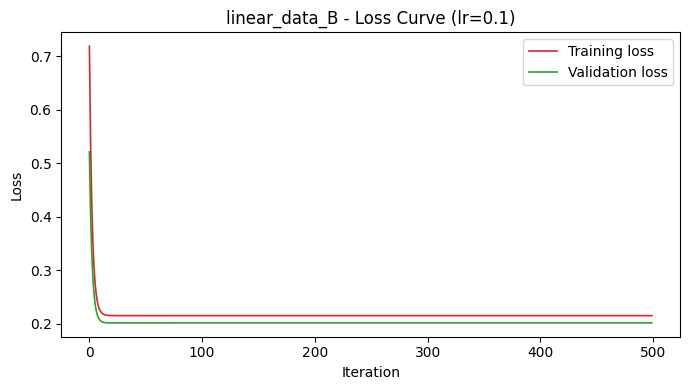

=== linear_data_B Evaluation (lr=0.1) ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
--------------------------------------------------------------------------------
Running lr=0.01


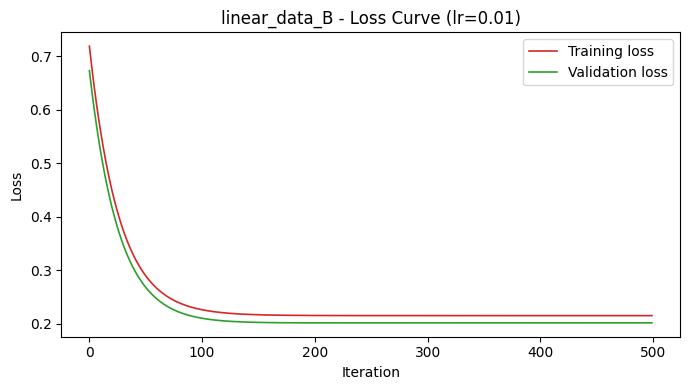

=== linear_data_B Evaluation (lr=0.01) ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
--------------------------------------------------------------------------------
Running lr=0.001


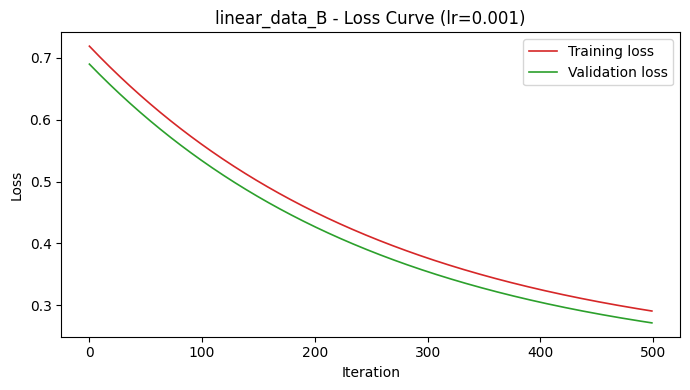

=== linear_data_B Evaluation (lr=0.001) ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011
Dataset: linear_data_C
--------------------------------------------------------------------------------
Running lr=0.1


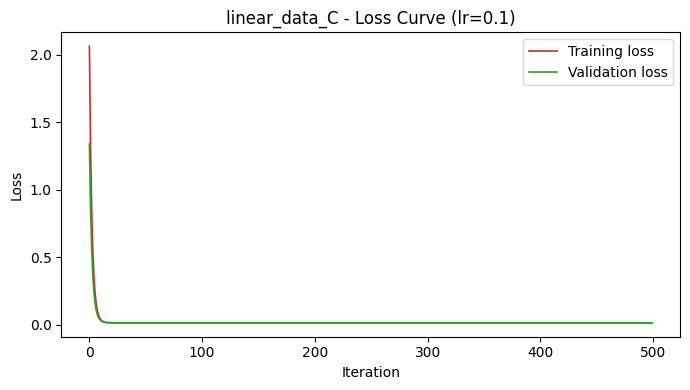

=== linear_data_C Evaluation (lr=0.1) ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
--------------------------------------------------------------------------------
Running lr=0.01


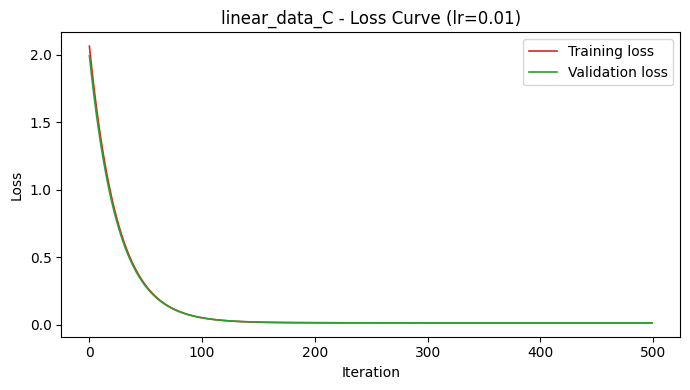

=== linear_data_C Evaluation (lr=0.01) ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
--------------------------------------------------------------------------------
Running lr=0.001


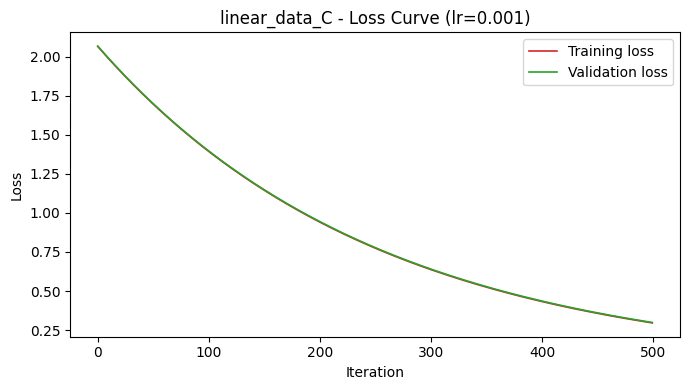

=== linear_data_C Evaluation (lr=0.001) ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994
Dataset: linear_data_D
--------------------------------------------------------------------------------
Running lr=0.1


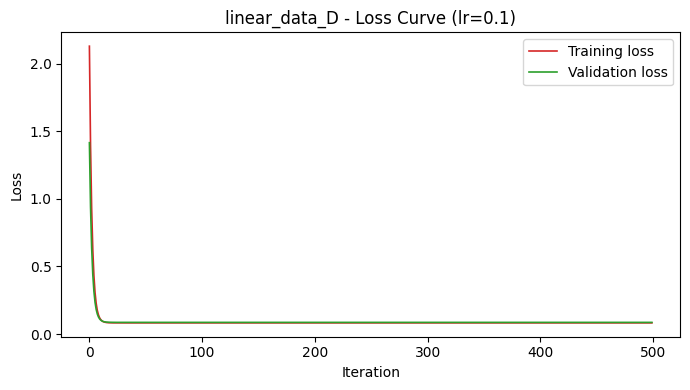

=== linear_data_D Evaluation (lr=0.1) ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
--------------------------------------------------------------------------------
Running lr=0.01


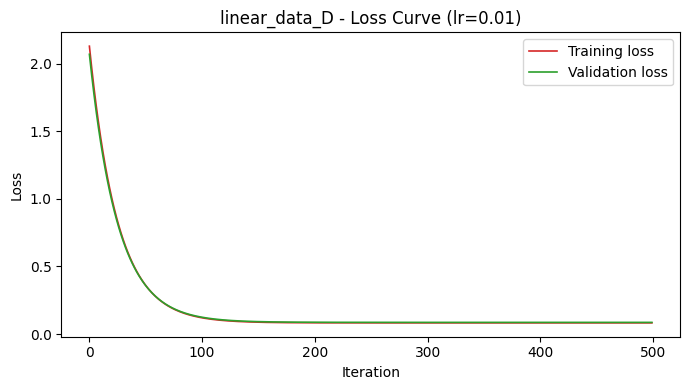

=== linear_data_D Evaluation (lr=0.01) ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
--------------------------------------------------------------------------------
Running lr=0.001


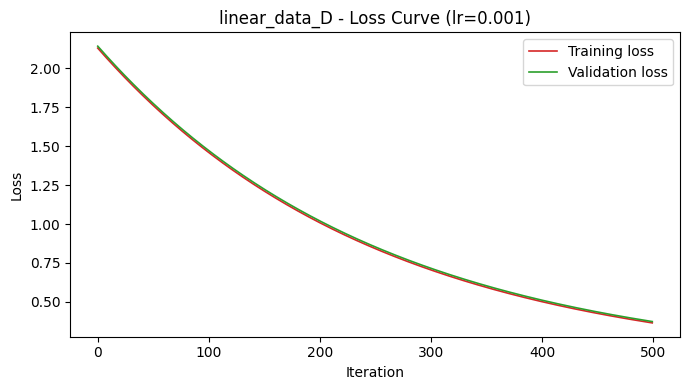

=== linear_data_D Evaluation (lr=0.001) ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


,dataset,learning_rate,MSE,MAE,RMSE,R-squared,loss_curve_path
0,linear_data_A,0.100,0.013356,0.100956,0.115570,0.568964,report_assets/linear_regression/linear_data_A_...
1,linear_data_A,0.010,0.013355,0.100951,0.115565,0.569000,report_assets/linear_regression/linear_data_A_...
2,linear_data_A,0.001,0.083156,0.236918,0.288369,-1.683627,report_assets/linear_regression/linear_data_A_...
3,linear_data_B,0.100,0.213701,0.403824,0.462278,0.044775,report_assets/linear_regression/linear_data_B_...
4,linear_data_B,0.010,0.213697,0.403819,0.462274,0.044796,report_assets/linear_regression/linear_data_B_...
5,linear_data_B,0.001,0.268702,0.440391,0.518365,-0.201071,report_assets/linear_regression/linear_data_B_...
6,linear_data_C,0.100,0.013183,0.098682,0.114816,0.995352,report_assets/linear_regression/linear_data_C_...
7,linear_data_C,0.010,0.013183,0.098681,0.114817,0.995352,report_assets/linear_regression/linear_data_C_...
8,linear_data_C,0.001,0.285225,0.427349,0.534065,0.899428,report_assets/linear_regression/linear_data_C_...
9,linear_data_D,0.100,0.082392,0.246706,0.287041,0.971606,report_assets/linear_regression/linear_data_D_...


In [3]:
linear_records = []

for dataset_name in DATASETS:
    print('=' * 80)
    print(f'Dataset: {dataset_name}')
    for lr in LEARNING_RATES:
        print('-' * 80)
        print(f'Running lr={lr}')
        result = run_single_experiment(dataset_name, lr)
        linear_records.append(result)

linear_results_df = pd.DataFrame(linear_records)
linear_results_df


In [4]:
linear_csv_path = asset_dir / 'linear_regression_metrics.csv'
linear_md_path = asset_dir / 'linear_regression_metrics.md'

linear_results_df.to_csv(linear_csv_path, index=False)
save_markdown_table(linear_results_df, linear_md_path)

print(f'Saved summary CSV: {linear_csv_path}')
print(f'Saved summary Markdown: {linear_md_path}')


Saved summary CSV: report_assets/linear_regression/linear_regression_metrics.csv
Saved summary Markdown: report_assets/linear_regression/linear_regression_metrics.md


## Q1(c): Observations

1. `lr=0.1` and `lr=0.01` converge to very similar final metrics on all four datasets.
2. `lr=0.001` usually converges much slower within 500 iterations and shows underfitting (higher MSE/MAE and lower R-squared).
3. Datasets `linear_data_C` and `linear_data_D` achieve high R-squared overall, while `linear_data_B` is noticeably harder (lower R-squared across all learning rates).

In [5]:
best_lr_df = (
    linear_results_df
    .sort_values(['dataset', 'MSE', 'MAE'])
    .groupby('dataset', as_index=False)
    .first()[['dataset', 'learning_rate', 'MSE', 'MAE', 'RMSE', 'R-squared']]
)

print('Best learning rate by MSE for each dataset:')
best_lr_df


Best learning rate by MSE for each dataset:


,dataset,learning_rate,MSE,MAE,RMSE,R-squared
0,linear_data_A,0.01,0.013355,0.100951,0.115565,0.569000
1,linear_data_B,0.01,0.213697,0.403819,0.462274,0.044796
2,linear_data_C,0.10,0.013183,0.098682,0.114816,0.995352
3,linear_data_D,0.10,0.082392,0.246706,0.287041,0.971606
